# Pipeline de Preparação de Dados
Este notebook implementa as etapas de limpeza, filtragem e temporalização conforme descrito nos slides 22–26 do projeto PainelConstru.

In [14]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv('datasets/products_4.csv')

0       PE
1       PE
2       SP
3       SP
4       BA
        ..
8803    SP
8804    RJ
8805    RJ
8806    RJ
8807    SP
Name: Proj_State, Length: 8808, dtype: object

In [3]:
# Remoção de colunas não utilizadas na modelagem
cols_to_drop = ['Prod_Desc', 'Sub_Name', 'ID_Proj', 'Proj_Name', 'Proj_City']
df_clean = df.drop(columns=cols_to_drop)
df_clean.head()

,Cat_Name,BOM_Quant,Proj_State,Proj_Date
0,Construção Civil,34.0,PE,2023-09-05
1,Construção Civil,355.0,PE,2023-09-05
2,Construção Civil,136.0,SP,2023-09-05
3,Infraestrutura,104.0,SP,2023-09-05
4,Infraestrutura,14.0,BA,2023-09-05


In [4]:
# Filtragem por estados e top 3 categorias
estados = ['RJ', 'SP', 'RS']
df_estados = df_clean[df_clean['Proj_State'].isin(estados)]
top3_cat = df_estados['Cat_Name'].value_counts().nlargest(3).index.tolist()
df_top3 = df_estados[df_estados['Cat_Name'].isin(top3_cat)]
df_top3.head()

,Cat_Name,BOM_Quant,Proj_State,Proj_Date
3,Infraestrutura,104.0,SP,2023-09-05
8,Infraestrutura,2.0,SP,2023-09-06
9,Infraestrutura,2.0,SP,2023-09-06
10,Infraestrutura,2.0,SP,2023-09-06
12,Materiais Elétricos,21.0,SP,2023-09-06


In [5]:
# Criação dos datasets segmentados por estado e categoria
bases_segmentadas = {}
for estado in estados:
    for cat in top3_cat:
        chave = f'{estado}_{cat.replace(" ", "_")}'
        base = df_top3[(df_top3['Proj_State'] == estado) & (df_top3['Cat_Name'] == cat)].copy()
        bases_segmentadas[chave] = base

In [6]:
# Agregação temporal semanal e quinzenal
bases_agregadas = {}
for nome, base in bases_segmentadas.items():
    base['Proj_Date'] = pd.to_datetime(base['Proj_Date'])
    semanal = base.resample('W-MON', on='Proj_Date')['BOM_Quant'].sum().reset_index()
    quinzenal = base.resample('2W-MON', on='Proj_Date')['BOM_Quant'].sum().reset_index()
    bases_agregadas[f'{nome}_semanal'] = semanal
    bases_agregadas[f'{nome}_quinzenal'] = quinzenal

In [7]:
# Exemplo de base agregada
bases_agregadas['RJ_Ferragens_semanal'].head()

,Proj_Date,BOM_Quant
0,2023-11-06,1.0
1,2023-11-13,0.0
2,2023-11-20,0.0
3,2023-11-27,0.0
4,2023-12-04,0.0


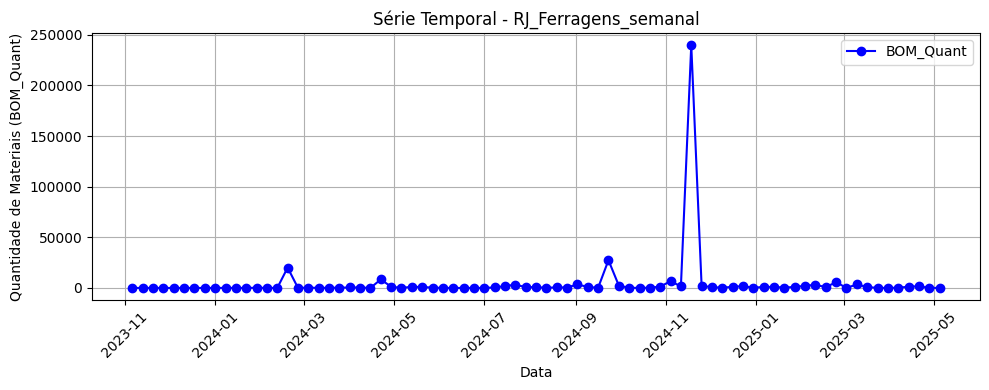

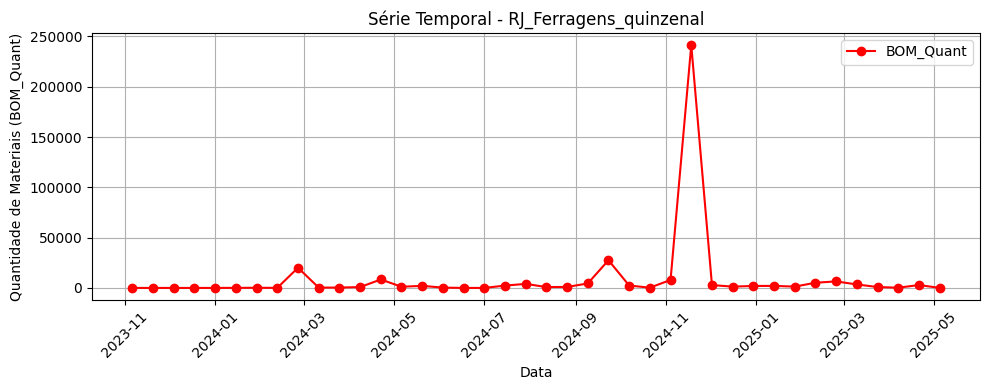

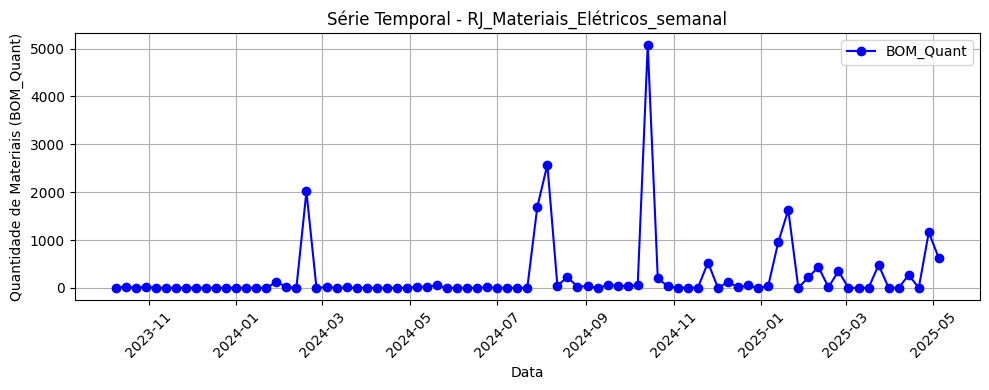

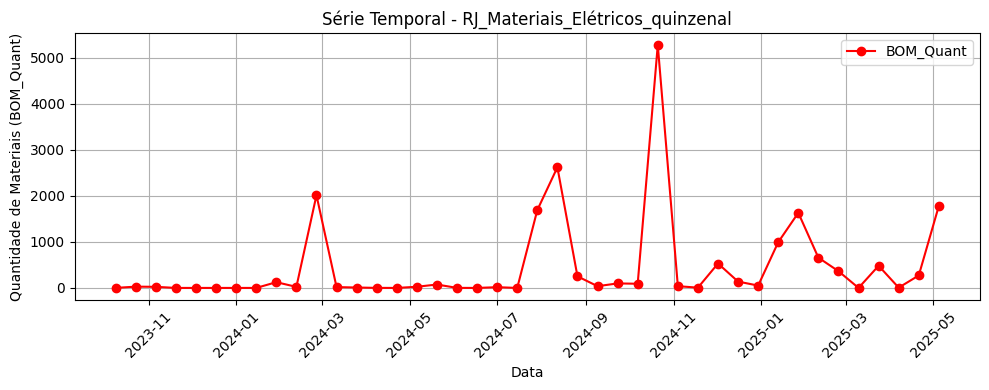

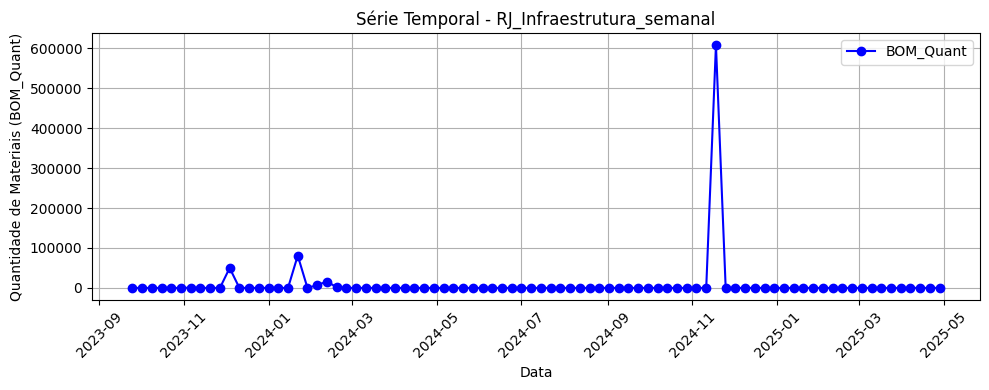

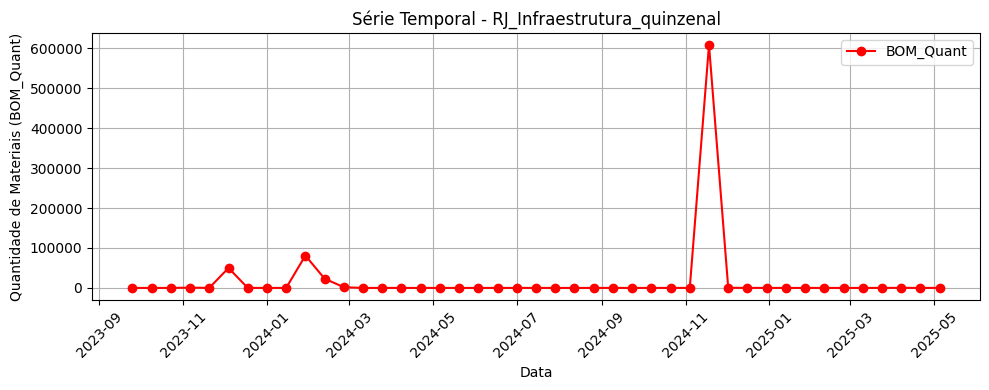

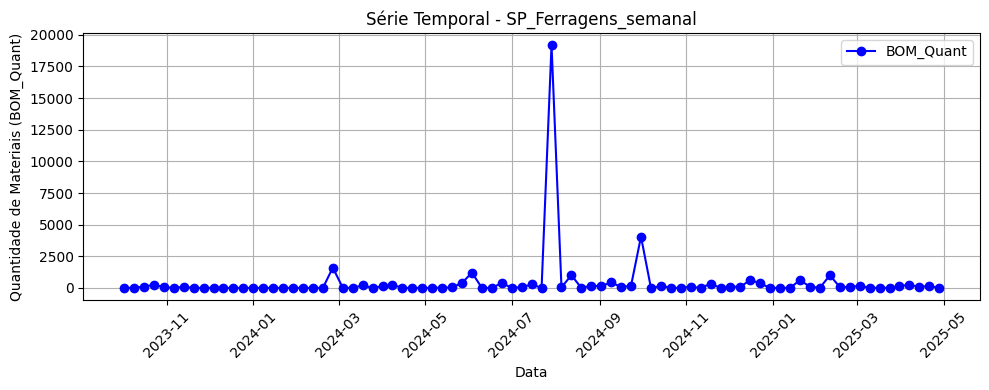

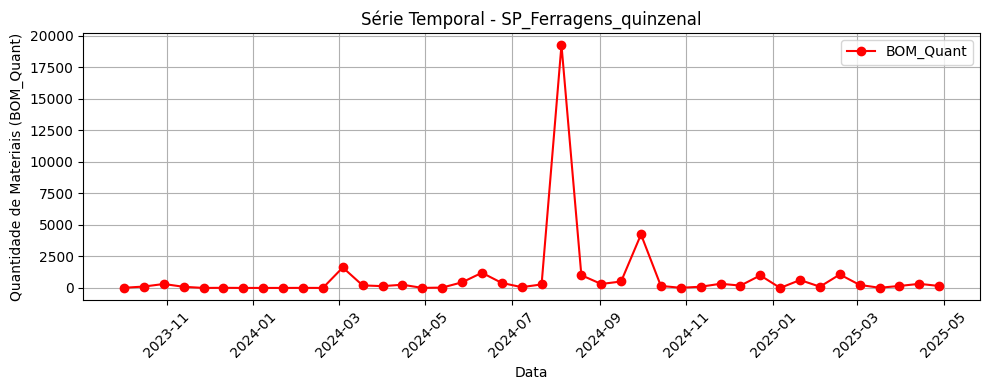

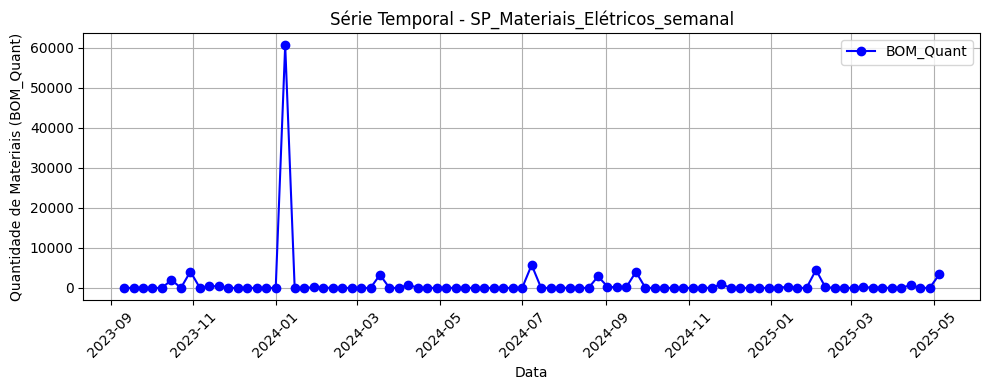

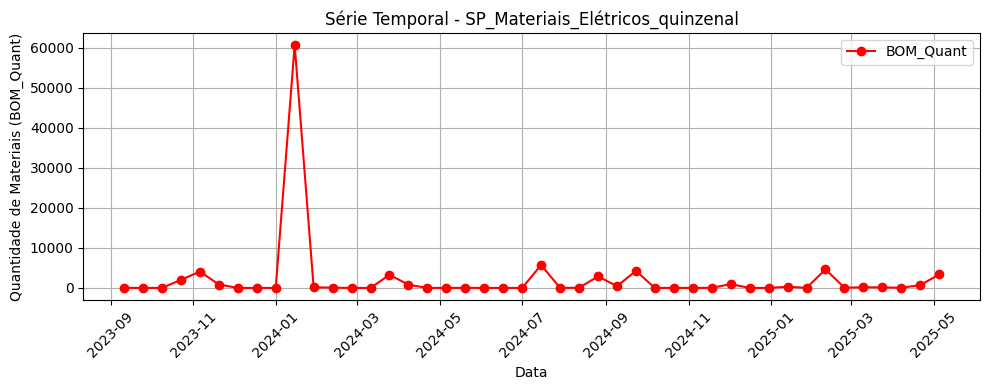

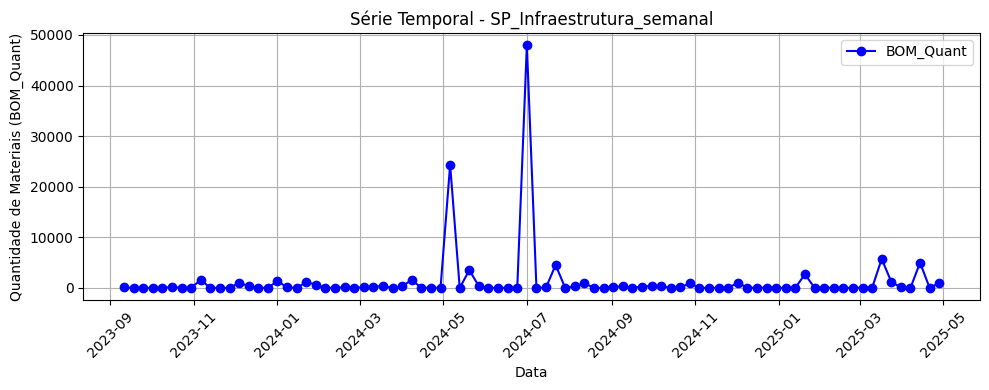

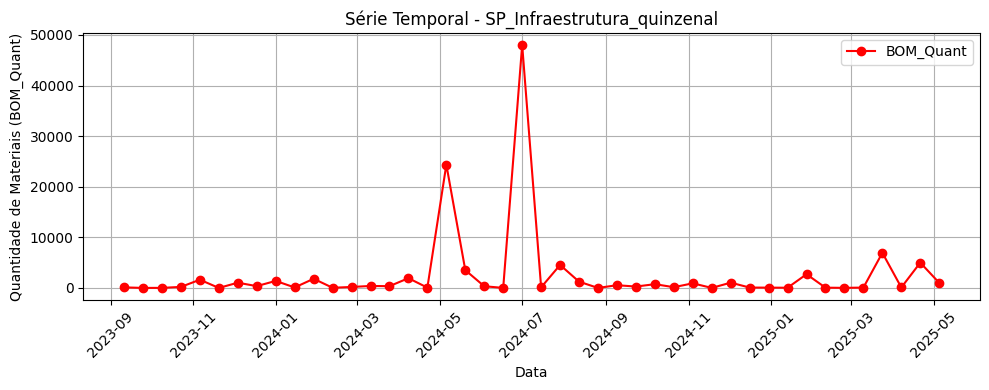

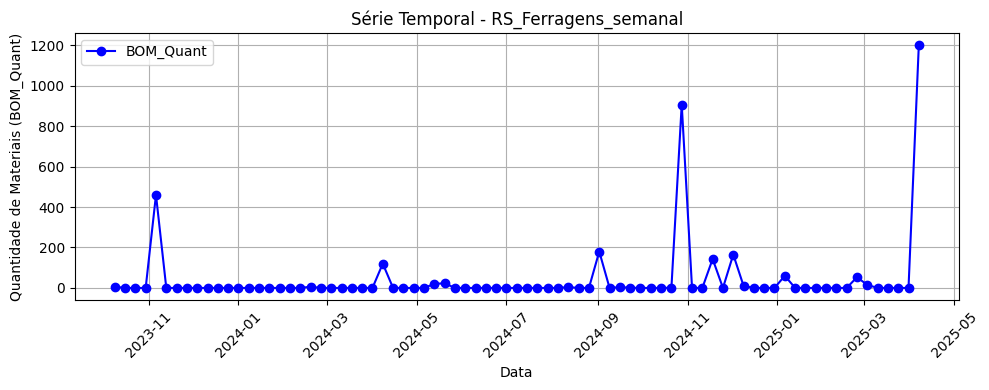

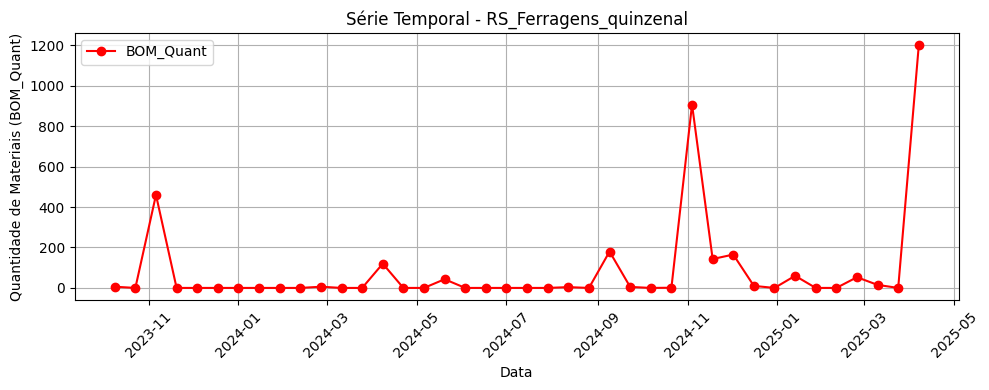

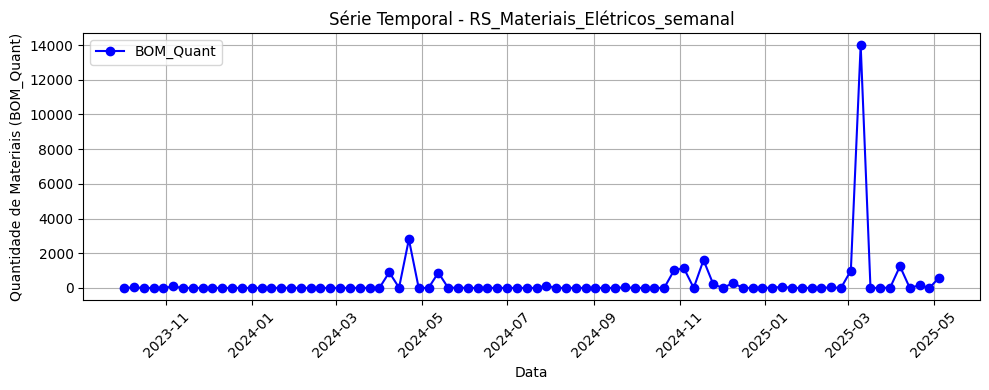

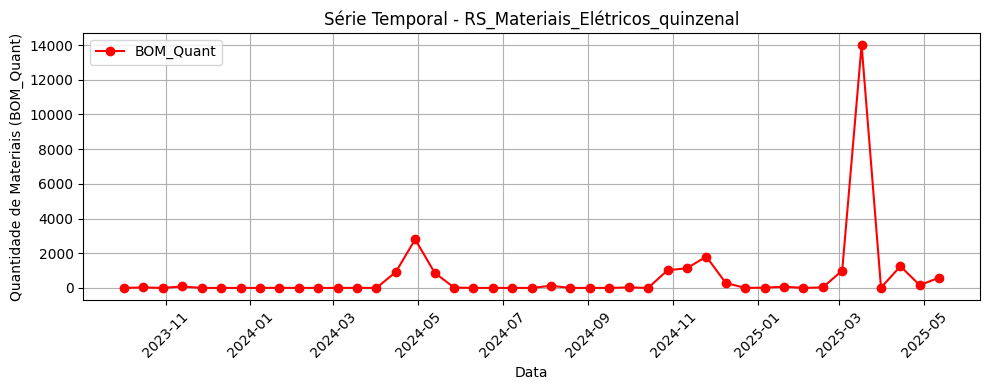

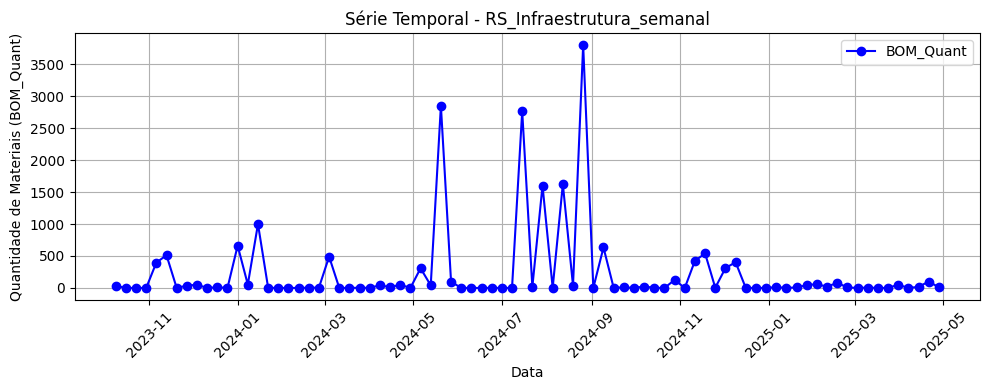

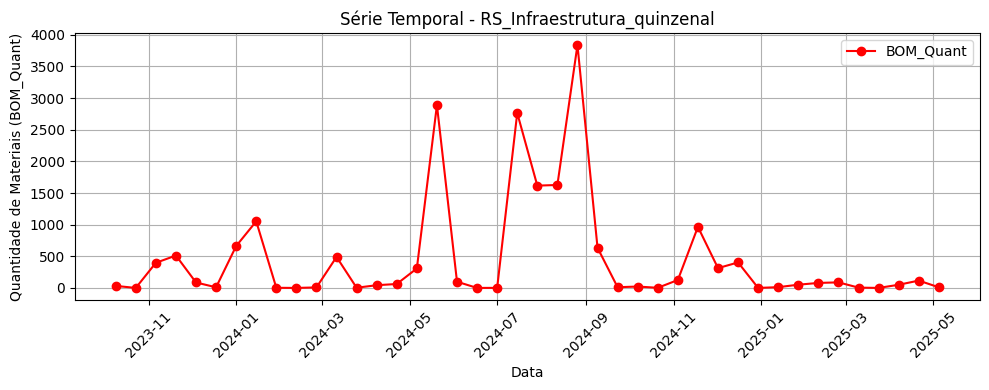

In [12]:
import matplotlib.pyplot as plt

%matplotlib inline

# Gera os gráficos com cores específicas
for nome, df in bases_agregadas.items():
    if "Proj_Date" in df.columns and "BOM_Quant" in df.columns:
        # Define a cor com base no nome
        cor = 'blue' if 'semanal' in nome else 'red'
        
        plt.figure(figsize=(10, 4))
        plt.plot(df["Proj_Date"], df["BOM_Quant"], marker='o', color=cor, label='BOM_Quant')
        plt.title(f"Série Temporal - {nome}")
        plt.xlabel("Data")
        plt.ylabel("Quantidade de Materiais (BOM_Quant)")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
